# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful **starting points** for the extension include:_

* **Stereo view synthesis:** Start from a **dense disparity map** (e.g. the motorcycle stereo pair in Part 2) and aim to **draw the scene again** as if a **second, shifted camera** had taken the picture- not just a false-color disparity plot.

* **Metric depth:** Turn disparities into **metric depth** with $\text{depth} = \frac{B \cdot f}{\text{disparity}}$ using a plausible **baseline** and **focal length**, and stabilize the denominator when disparity is tiny or noisy.

* **Calibration & lifting:** Use the camera **intrinsics** ($3 \times 3$ matrix $K$) together with disparity and baseline to **lift pixels from the image into 3D** in the original camera’s coordinate frame.

* **Virtual camera motion:** Describe how the new camera sits relative to the first with a **rigid motion**—a **rotation** and **translation**—and **move every 3D point** into that new camera’s frame before drawing.

* **Rendering:** **Project** those 3D points back onto a **fresh image grid** with intrinsics suited to the new view, producing the **rerendered photograph** (including how you handle resolution, bounds, and empty pixels).

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: Huang, Qihao. Object-Centric Stereo Ranging for Autonomous Driving: From Dense Disparity to Census-Based Template Matching. arXiv, 2026, arXiv:2604.07980v1.
  *   This paper presents a stereo vision system for autonomous driving that estimates depth using three complementary methods: dense stereo disparity (BM/SGM), object-centric Census-based template matching, and monocular geometric priors. Its main contribution is a sparse object-level stereo matching approach that computes disparity only inside detected object bounding boxes rather than across the full image, greatly reducing computation while improving long-range accuracy.  
* Source 2: Mohile, Jay. Stereoscopic Point Cloud Generation. GitHub, https://github.com/jamohile/stereoscopic-point-clouds.
  *   This repository implements a stereo-based 3D reconstruction pipeline that converts left and right stereo images into a 3D point cloud through disparity estimation, triangulation, and post-processing. The method computes a dense disparity map by matching each pixel in the left image with a similar pixel in the right image using normalized region matching while constraining the search to horizontal disparities for efficiency.  
* Source 3: Peasley, Brian. 3D Point Cloud Construction from Stereo Images. Department of Electrical and Computer Engineering, Clemson University.  
  *   This paper proposes a low-cost method for reconstructing 3D point clouds from stereo image pairs instead of using expensive laser scanners. Using synthetic stereo images generated in Blender, the author computes disparities between corresponding feature points with the Lucas–Kanade tracking algorithm and converts those disparities into approximate depth values.
* Source 4: “Reproject Disparity Images to 3D Point Clouds.” MultiSense Docs, Carnegie Robotics, MultiSense Cookbook Documentation.
  *   The Carnegie Robotics MultiSense documentation describes a practical stereo vision pipeline used in robotics systems to convert rectified stereo images into 3D point clouds. The documentation explains how disparity images can be reprojected into metric 3D coordinates using the stereo camera calibration and reprojection matrix Q, which is constructed from the cameras’ intrinsic and extrinsic calibration parameters.
* Source 5: “Camera Calibration and 3D Reconstruction.” OpenCV Documentation, OpenCV, OpenCV calib3d Documentation.
  *   The OpenCV calib3d module documentation describes a comprehensive set of tools for camera calibration, stereo vision, and 3D reconstruction. The module includes functions for estimating camera intrinsics and extrinsics, computing epipolar geometry, stereo rectification, disparity estimation, and reprojecting disparity maps into 3D point clouds. In particular, functions such as findFundamentalMat, stereoCalibrate, and reprojectImageTo3D form the core of stereo reconstruction workflows.

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You are not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
import os

if not os.path.exists("CS131_release"):
    # Clone the repository if it doesn't already exist
    !git clone https://github.com/miaxiaozl/CS131.git

%cd CS131/spring_2026/project2_release/option_B

fatal: destination path 'CS131' already exists and is not an empty directory.
/content/CS131/spring_2026/project2_release/option_B


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from scipy.ndimage import median_filter
from matplotlib.patches import Rectangle

In [3]:
plt.rcParams['figure.figsize'] = (12.0, 9.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

## From Non-Exploration Notebook

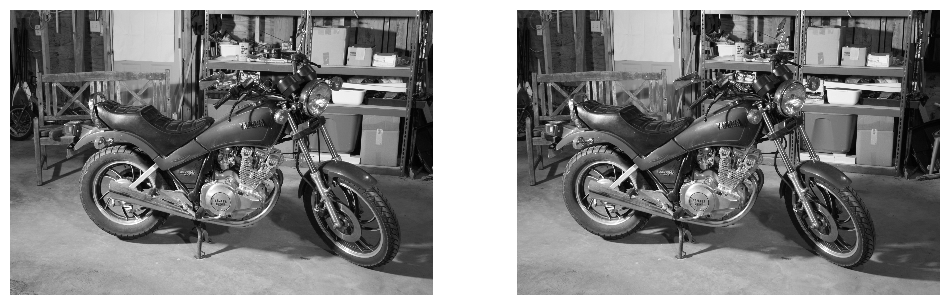

In [4]:
img1 = cv.imread('motorcycle_left.png', cv.IMREAD_GRAYSCALE)
img2 = cv.imread('motorcycle_right.png', cv.IMREAD_GRAYSCALE)

plt.subplot(121)
plt.imshow(img1)
plt.axis('off')
plt.subplot(122)
plt.imshow(img2)
plt.axis('off')
plt.show()

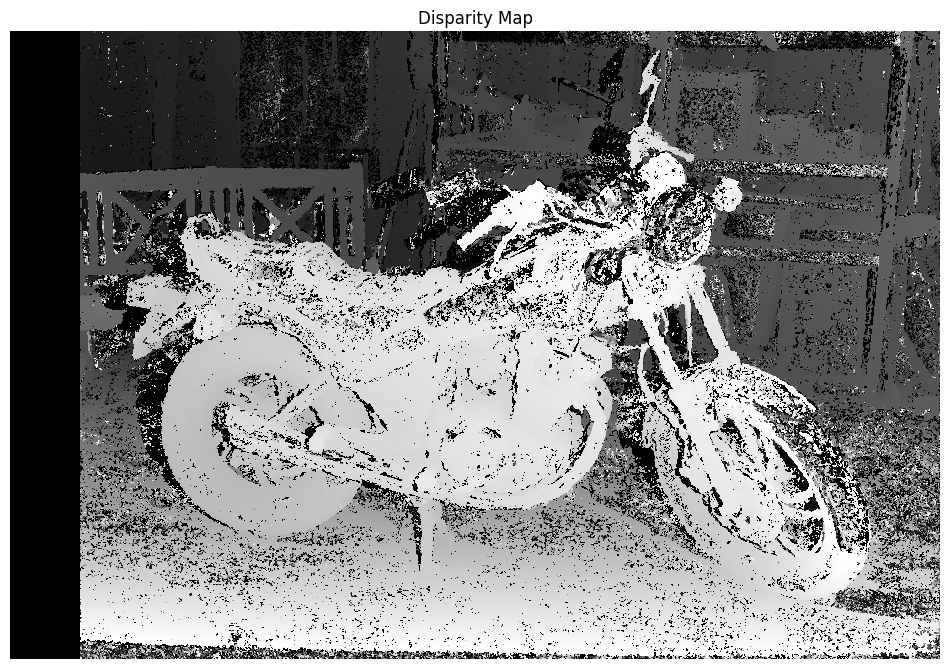

In [5]:
stereo = cv.StereoSGBM_create(minDisparity=16, numDisparities=208, blockSize=7)
disparity = stereo.compute(img1, img2).astype(np.float32) / 16.0

plt.imshow(disparity)
plt.axis('off')
plt.title('Disparity Map')
plt.show()

## Exploration: 3D Point Cloud (Unsuccessful)

min: 15.0
5th percentile: 15.0
25th percentile: 40.25
median: 90.6875
75th percentile: 191.375
95th percentile: 215.0625
max: 223.0


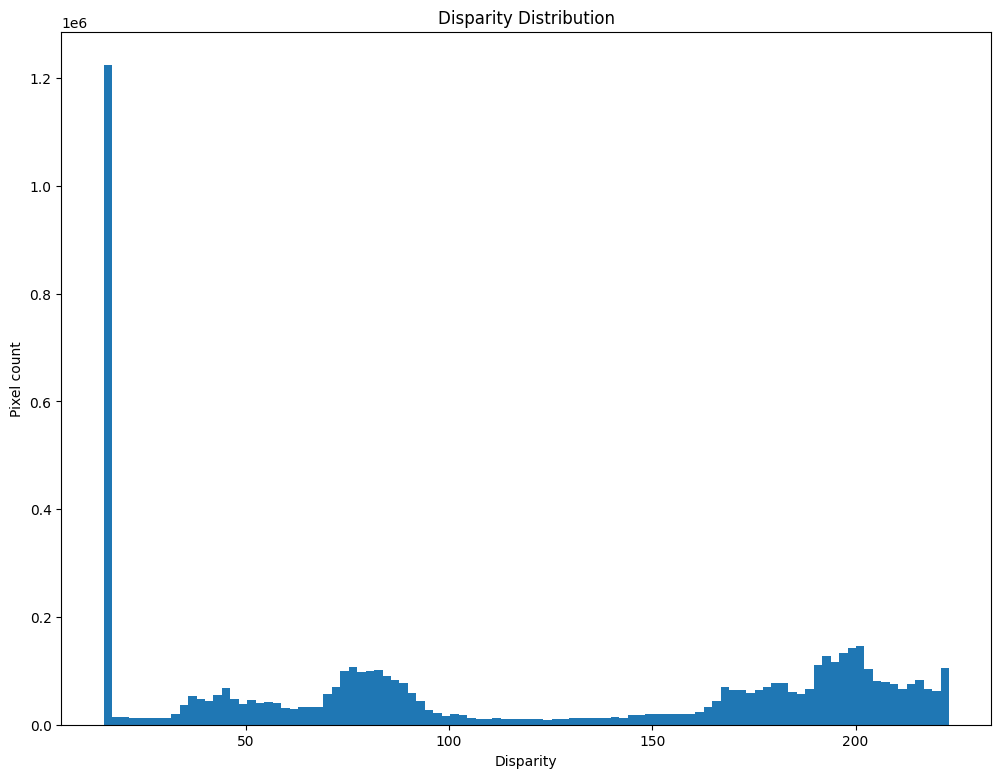

In [37]:
# Look only at non-invalid disparities
disp_valid = disparity[np.isfinite(disparity) & (disparity > 0)]

print("min:", np.min(disp_valid))
print("5th percentile:", np.percentile(disp_valid, 5))
print("25th percentile:", np.percentile(disp_valid, 25))
print("median:", np.percentile(disp_valid, 50))
print("75th percentile:", np.percentile(disp_valid, 75))
print("95th percentile:", np.percentile(disp_valid, 95))
print("max:", np.max(disp_valid))

plt.hist(disp_valid, bins=100)
plt.xlabel("Disparity")
plt.ylabel("Pixel count")
plt.title("Disparity Distribution")
plt.show()

In [38]:
H, W = img1.shape

# Assumed camera parameters
fx = 700.0
fy = 700.0
cx = W / 2
cy = H / 2
B = 0.10   # baseline in meters

disp = median_filter(disparity, size=7)

# Manual motorcycle ROI
# Adjust these values after looking at the mask.
roi = np.zeros_like(img1, dtype=bool)
y1, y2 = int(0.15 * H), int(0.90 * H)
x1, x2 = int(0.15 * W), int(0.93 * W)
roi[y1:y2, x1:x2] = True

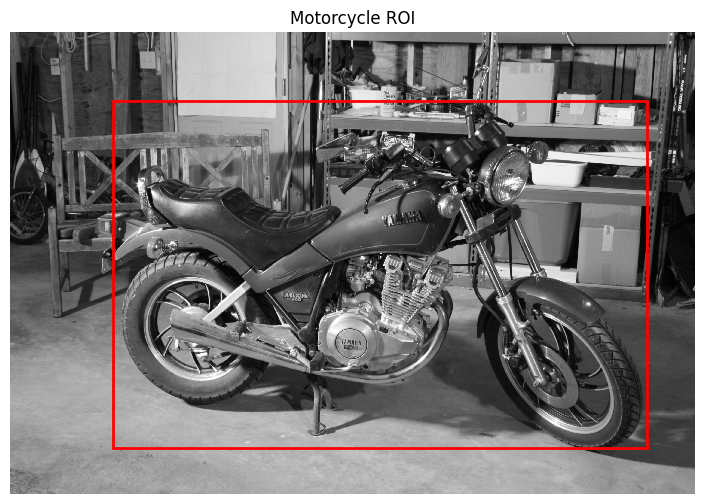

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(img1, cmap='gray')

rect = Rectangle(
    (x1, y1),
    x2 - x1,
    y2 - y1,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

ax.add_patch(rect)

ax.set_title('Motorcycle ROI')
ax.axis('off')

plt.show()

In [40]:
# Keep only reasonable, confident disparities inside ROI
valid_disp = (disp > 16) & roi
depth = np.full_like(disp, np.nan, dtype=np.float32)
depth[valid_disp] = fx * B / disp[valid_disp]

# Use depth range to remove bad far/near points
valid = (
    np.isfinite(depth)
    & (depth > 0.25)
    & (depth < 0.55)
    & roi
)

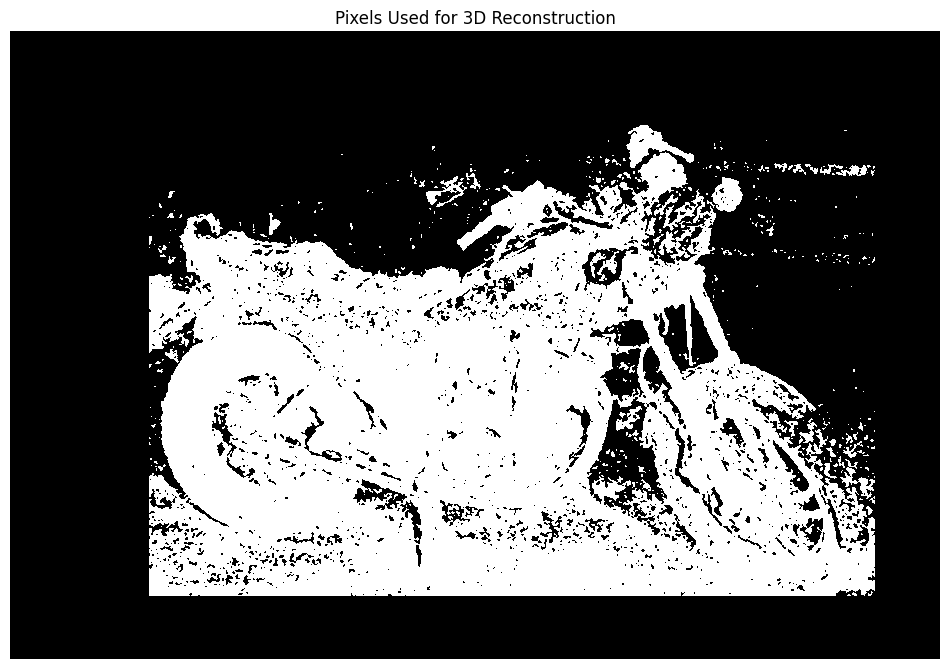

In [41]:
plt.imshow(valid, cmap='gray')
plt.axis('off')
plt.title('Pixels Used for 3D Reconstruction')
plt.show()

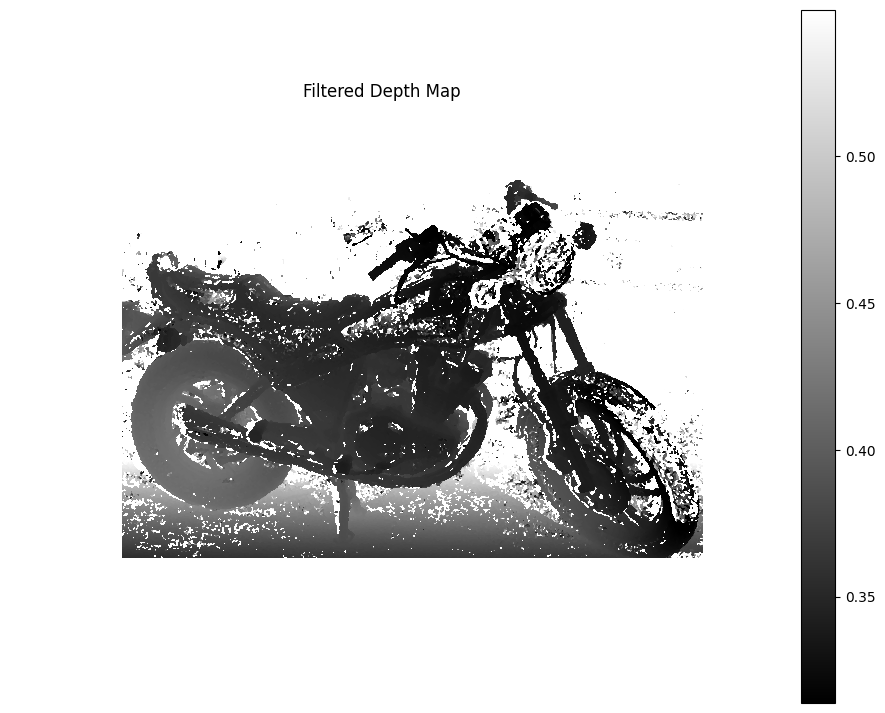

In [42]:
plt.imshow(np.where(valid, depth, np.nan))
plt.axis('off')
plt.title('Filtered Depth Map')
plt.colorbar()
plt.show()

In [46]:
ys, xs = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

Z_raw = depth[valid]
# Exaggerate depth variation for visualization
Z_center = np.nanmedian(Z_raw)
depth_exaggeration = 4.0

Z = Z_center + depth_exaggeration * (Z_raw - Z_center)

X = (xs[valid] - cx) * Z / fx
Y = (ys[valid] - cy) * Z / fy

points_3d = np.stack([X, Y, Z], axis=1)
colors = img1[valid] / 255.0

print(points_3d.shape)

(2087984, 3)


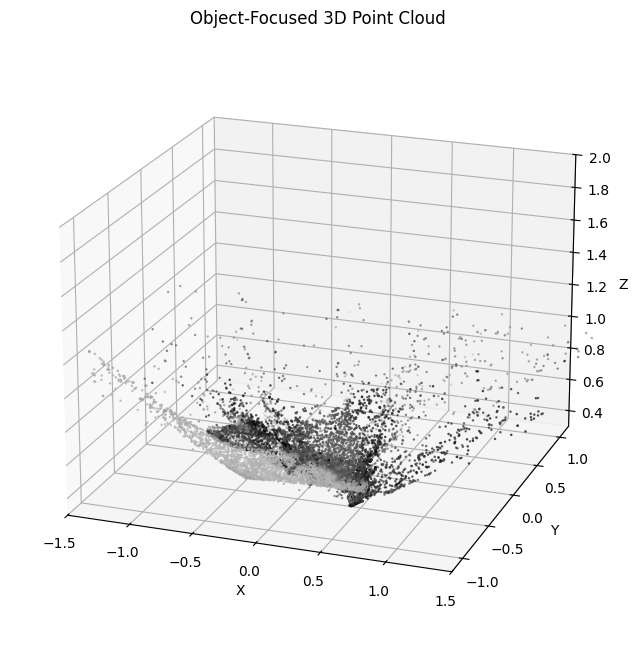

In [66]:
num_points = min(20000, points_3d.shape[0])
idx = np.random.choice(points_3d.shape[0], size=num_points, replace=False)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    points_3d[idx, 0],
    -points_3d[idx, 1],
    points_3d[idx, 2],
    c=colors[idx],
    cmap='gray',
    s=0.6
)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Object-Focused 3D Point Cloud')

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.2, 1.2)
ax.set_zlim(0.3, 2.0)

ax.view_init(elev=20, azim=-70)
plt.show()

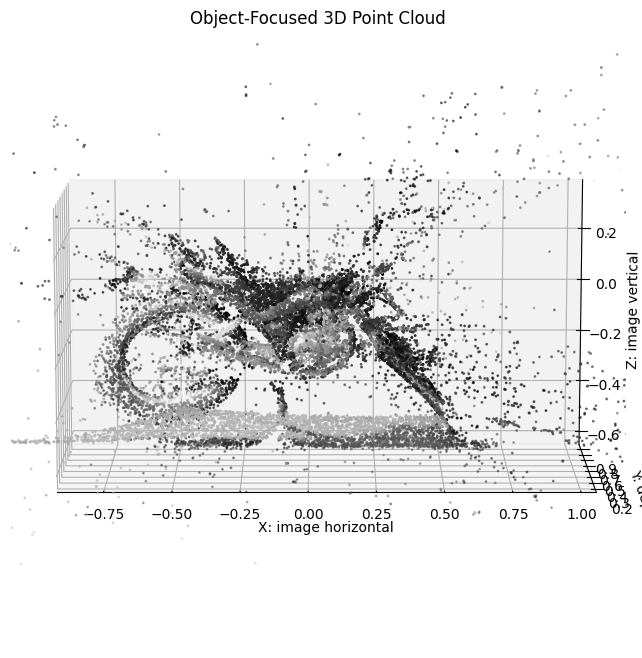

In [76]:
pts = points_3d[idx]

x_plot = pts[:, 0]
y_plot = pts[:, 2]
z_plot = -pts[:, 1]

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x_plot,
    y_plot,
    z_plot,
    c=colors[idx],
    cmap='gray',
    s=1.0
)

# Robust bounds
x_low, x_high = np.percentile(x_plot, [1, 99])
y_low, y_high = np.percentile(y_plot, [1, 99])
z_low, z_high = np.percentile(z_plot, [1, 99])

ax.set_xlim(x_low, x_high)
ax.set_ylim(y_low, y_high)
ax.set_zlim(z_low, z_high)

ax.set_xlabel('X: image horizontal')
ax.set_ylabel('Y: depth')
ax.set_zlabel('Z: image vertical')

ax.set_title('Object-Focused 3D Point Cloud')

ax.set_box_aspect((
    x_high - x_low,
    y_high - y_low,
    z_high - z_low
))

# View from front/above
ax.view_init(elev=10, azim=-90)     # side view showing depth
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

In this exploration, I extended the stereo disparity pipeline from the main notebook into a basic 3D reconstruction workflow using stereo geometry. My goal was to investigate how disparity maps can be converted into approximate scene structure by lifting image pixels into 3D coordinates through triangulation. Using OpenCV’s StereoSGBM, I first computed a dense disparity map and then converted disparity into approximate depth values using the stereo depth relationship $Z=\frac{fB}{d}$ with assumed camera intrinsics and stereo baseline parameters.

I then back-projected valid pixels into 3D coordinates to generate point clouds of the motorcycle scene. To improve reconstruction quality, I experimented with disparity filtering, ROI masking, percentile-based thresholding, and depth constraints in order to isolate reliable foreground structure and reduce noisy background points. These experiments revealed that stereo reconstruction quality is highly sensitive to disparity noise, especially in scenes containing reflective surfaces, shadows, thin structures, and repeated textures. Although the resulting point clouds remained noisy and inaccurate, the exploration demonstrated both the geometric foundations of stereo reconstruction and the practical challenges involved in converting dense disparity maps into stable 3D scene structure.